In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv(r'../pre-calculated_data/mag_gtdb_r226.txt',sep='\t')
df = df[['Mag ID','Drep_95','GTDB']]
df = df[df['Drep_95']=='T']
unknown = df[df['GTDB'].isna()]
df

,Mag ID,Drep_95,GTDB
0,cpsnj01_SemiBin_0,T,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
1,cpsnj01_SemiBin_10,T,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...
2,cpsnj01_SemiBin_110,T,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...
3,cpsnj01_SemiBin_112,T,d__Bacteria;p__Chloroflexota;c__Chloroflexia;o...
5,cpsnj01_SemiBin_118,T,d__Bacteria;p__Chloroflexota;c__Limnocylindria...
...,...,...,...
7943,snj20_SemiBin_94,T,d__Bacteria;p__Patescibacteriota;c__Saccharimo...
7944,snj20_SemiBin_95,T,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...
7945,snj20_SemiBin_963,T,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...
7947,snj20_SemiBin_97,T,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...


In [3]:
df = df.dropna(subset=['GTDB'])
df['GTDB'] = df['GTDB'].str.rstrip(';p__;c__;o__;f__;g__;s__')
df['GTDB'] = df['GTDB'].str.rstrip(';c__;o__;f__;g__;s__')
df['GTDB'] = df['GTDB'].str.rstrip(';o__;f__;g__;s__')
df['GTDB'] = df['GTDB'].str.rstrip(';f__;g__;s__')
df['GTDB'] = df['GTDB'].str.rstrip(';g__;s__')
df['GTDB'] = df['GTDB'].str.rstrip(';s__')
df['tax_rank'] = df['GTDB'].str.split(';').map(len)
s = len(df[df['tax_rank'].isin([7])])
g = len(df[df['tax_rank'].isin([6,7])])
f = len(df[df['tax_rank'].isin([5,6,7])])
o = len(df[df['tax_rank'].isin([4,5,6,7])])
c = len(df[df['tax_rank'].isin([3,4,5,6,7])])
p = len(df[df['tax_rank'].isin([2,3,4,5,6,7])])
d = len(df[df['tax_rank'].isin([1,2,3,4,5,6,7])])
data = [
    ['Domain',d],
    ['Phylum',p],
    ['Class',c],
    ['Order',o],
    ['Family',f],
    ['Genus',g],
    ['Species',s]
]
sgb_tax = pd.DataFrame(data, columns=['Rank', 'Number of annotated SGBs'])
sgb_tax['Fraction'] = sgb_tax['Number of annotated SGBs'] * 100 /4171
sgb_tax = sgb_tax.drop(['Number of annotated SGBs'],axis=1)
sgb_tax = sgb_tax.set_index('Rank')
sgb_tax

<ipython-input-3-7782ce15cf08>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['GTDB'] = df['GTDB'].str.rstrip(';p__;c__;o__;f__;g__;s__')
<ipython-input-3-7782ce15cf08>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['GTDB'] = df['GTDB'].str.rstrip(';c__;o__;f__;g__;s__')
<ipython-input-3-7782ce15cf08>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

,Fraction
Rank,
Domain,99.760249
Phylum,99.688324
Class,99.688324
Order,99.160873
Family,98.297770
Genus,82.522177
Species,3.308559


[Text(0, 0.5, 'Fraction of SGBs (%)')]

<Figure size 432x288 with 0 Axes>

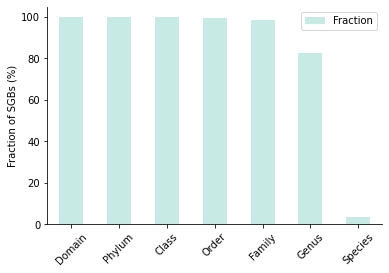

In [4]:
fig = plt.figure()
ax =sgb_tax.plot.bar(stacked=True,color='#c7eae5')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
ax.set(xlabel="")
ax.set(ylabel="Fraction of SGBs (%)")

In [5]:
df = pd.read_csv(r'../pre-calculated_data/mag_gtdb_r226.txt',sep='\t')
df = df[['Mag ID','Drep_95','GTDB']]
df = df[df['Drep_95']=='T']
df_tax = df['GTDB'].str.split(';', expand=True)
df_tax.columns = ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
df_tax

,Domain,Phylum,Class,Order,Family,Genus,Species
0,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Chitinophagales,f__Chitinophagaceae,g__Flavihumibacter,s__
1,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__UBA2999,g__Gp6-AA40,s__
2,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__DASTBU01,s__
3,d__Bacteria,p__Chloroflexota,c__Chloroflexia,o__Thermomicrobiales,f__UBA6265,g__JACCXM01,s__JACCXM01 sp036280495
5,d__Bacteria,p__Chloroflexota,c__Limnocylindria,o__Limnocylindrales,f__CSP1-4,g__DASTYU01,s__
...,...,...,...,...,...,...,...
7943,d__Bacteria,p__Patescibacteriota,c__Saccharimonadia,o__Saccharimonadales,f__UBA4665,g__JAGXIT01,s__
7944,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae,g__Sphingomicrobium,s__
7945,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACDCA01,s__
7947,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae,g__Sphingomicrobium,s__


([<matplotlib.patches.Wedge at 0x180ee508580>,
 [Text(-0.032385290303383635, -1.0995231661824891, 'Bacteria'),
  Text(0.03680156130230014, 1.2494581405896372, 'Archaea')],
 [Text(-0.017664703801845618, -0.5997399088268122, '99.06%'),
  Text(0.02208093678138008, 0.7496748843537822, '0.94%')])

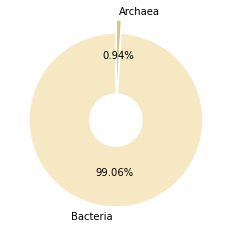

In [6]:
df_tax['Domain'].value_counts()
data = [4122,39]
classes = ['Bacteria', 'Archaea']
explode = [0, 0.15]
plt.pie(data,
        labels=classes,
        colors=['#f6e8c3', '#dfc27d'],
        explode=explode,
        autopct='%.2f%%',
        startangle=90, 
        wedgeprops={'width': 0.7, 'edgecolor': 'white', 'linewidth': 1.5}
        )

In [9]:
df_tax['Phylum'].value_counts()
df=df_tax
df['Phylum'] = df['Phylum'].fillna('Unknown')
df.loc[df['Phylum'].str.strip().str.lower() == 'p__', 'Phylum'] = 'Unknown'
phylum_counts = df['Phylum'].value_counts()
top_6 = phylum_counts.head(6)
other_count = phylum_counts[~phylum_counts.index.isin(top_6.index) & (phylum_counts.index != 'Unknown')].sum()
unknown_count = phylum_counts.get('Unknown', 0)

In [10]:
final_counts = top_6.copy()
final_counts['Other'] = other_count
final_counts['Unknown'] = unknown_count
final_counts

Phylum
p__Acidobacteriota    1251
p__Pseudomonadota      950
p__Gemmatimonadota     282
p__Actinomycetota      247
p__Bacteroidota        206
p__Chloroflexota       170
Other                 1052
Unknown                 13
Name: count, dtype: int64

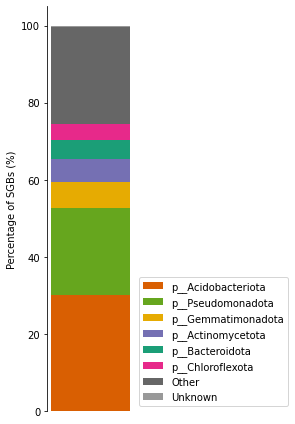

In [14]:
fig, ax = plt.subplots(figsize=(4.2,6))
ALL = 4171
x = 'taxonomy'
y8 = final_counts['Unknown'] *100 / ALL
y7 = final_counts['Other'] *100/ ALL
y6 = final_counts['p__Chloroflexota'] *100/ ALL
y5 = final_counts['p__Bacteroidota'] *100/ ALL
y4 = final_counts['p__Actinomycetota'] *100/ ALL
y3 = final_counts['p__Gemmatimonadota'] *100/ ALL
y2 = final_counts['p__Pseudomonadota'] *100/ ALL
y1 = final_counts['p__Acidobacteriota'] *100/ ALL

plt.bar(x,y1,color='#d95f02',label='p__Acidobacteriota')
plt.bar(x,y2,bottom=y1,color='#66a61e',label='p__Pseudomonadota')
plt.bar(x,y3,bottom=y1+y2,color='#e6ab02',label='p__Gemmatimonadota')
plt.bar(x,y4,bottom=y1+y2+y3,color='#7570b3',label='p__Actinomycetota')
plt.bar(x,y5,bottom=y1+y2+y3+y4,color='#1b9e77',label='p__Bacteroidota')
plt.bar(x,y6,bottom=y1+y2+y3+y4+y5,color='#e7298a',label='p__Chloroflexota')
plt.bar(x,y7,bottom=y1+y2+y3+y4+y5+y6,color='#666666',label='Other')
plt.bar(x,y8,bottom=y1+y2+y3+y4+y5+y6+y7,color='#999999',label='Unknown')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.xticks([]) 
plt.ylabel('Percentage of SGBs (%)')
plt.legend(loc=3,bbox_to_anchor=(1,0),ncol=1)
plt.tight_layout()